In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [66]:
# Load Dataset

df = pd.read_csv("/content/drive/MyDrive/AI-Project-5th-Sem/cleaned_football_dataset_final.csv")

In [67]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50149, 44)


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50149 entries, 0 to 50148
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country_of_citizenship                49880 non-null  object 
 1   date_of_birth                         50100 non-null  object 
 2   sub_position                          49563 non-null  object 
 3   position                              50149 non-null  object 
 4   foot                                  44256 non-null  object 
 5   height_in_cm                          45784 non-null  float64
 6   contract_expiration_date              31581 non-null  object 
 7   international_caps                    50149 non-null  int64  
 8   international_goals                   19356 non-null  float64
 9   current_club_domestic_competition_id  47163 non-null  object 
 10  current_club_name                     47163 non-null  object 
 11  market_value_in

In [69]:
target_columns = [
    "Player_Future_Potential_Score",
    "Player_Future_Potential_Rating"
]

# Numerical columns
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Object columns
object_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

# Date columns stored as object in the CSV
date_columns = [
    "date_of_birth",
    "contract_expiration_date"
]

# Categorical columns
categorical_columns = [
    col for col in object_columns
    if col not in date_columns
    and col not in target_columns
]

# Target columns
target_present = [
    col for col in target_columns
    if col in df.columns
]

print("=" * 60)
print("COLUMN TYPE ANALYSIS")
print("=" * 60)

print("\nNumerical columns:")
for col in numerical_columns:
    print("-", col)

print("\nDate columns:")
for col in date_columns:
    print("-", col)

print("\nCategorical / text columns:")
for col in categorical_columns:
    print("-", col)

print("\nTarget columns:")
for col in target_present:
    print("-", col)

print("\nCounts:")
print("Numerical:", len(numerical_columns))
print("Date:", len(date_columns))
print("Categorical/Text:", len(categorical_columns))
print("Targets:", len(target_present))

COLUMN TYPE ANALYSIS

Numerical columns:
- height_in_cm
- international_caps
- international_goals
- market_value_in_eur
- highest_market_value_in_eur
- matches_played
- total_minutes
- avg_minutes
- total_goals
- avg_goals
- total_assists
- avg_assists
- yellow_cards
- red_cards
- value_growth
- transfer_count
- total_transfer_fee
- highest_transfer_fee
- squad_size
- average_age
- foreigners_number
- foreigners_percentage
- national_team_players
- stadium_seats
- total_clubs
- Player_Future_Potential_Score

Date columns:
- date_of_birth
- contract_expiration_date

Categorical / text columns:
- country_of_citizenship
- sub_position
- position
- foot
- current_club_domestic_competition_id
- current_club_name
- stadium_name
- net_transfer_record
- competition_code
- name
- sub_type
- type
- country_name
- domestic_league_code
- confederation

Target columns:
- Player_Future_Potential_Score
- Player_Future_Potential_Rating

Counts:
Numerical: 26
Date: 2
Categorical/Text: 15
Targets: 2


In [70]:
pca_features = [
    col for col in numerical_columns
    if col not in target_columns
]

print("=" * 60)
print("PCA INPUT FEATURES")
print("=" * 60)

for i, col in enumerate(pca_features, 1):
    print(f"{i}. {col}")

print("\nTotal numerical input features for PCA:", len(pca_features))

PCA INPUT FEATURES
1. height_in_cm
2. international_caps
3. international_goals
4. market_value_in_eur
5. highest_market_value_in_eur
6. matches_played
7. total_minutes
8. avg_minutes
9. total_goals
10. avg_goals
11. total_assists
12. avg_assists
13. yellow_cards
14. red_cards
15. value_growth
16. transfer_count
17. total_transfer_fee
18. highest_transfer_fee
19. squad_size
20. average_age
21. foreigners_number
22. foreigners_percentage
23. national_team_players
24. stadium_seats
25. total_clubs

Total numerical input features for PCA: 25


In [71]:
missing_count = df[pca_features].isnull().sum()

missing_percentage = (
    df[pca_features].isnull().mean() * 100
)

missing_summary = pd.DataFrame({
    "Column": pca_features,
    "Missing_Count": missing_count.values,
    "Missing_Percentage": missing_percentage.values
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

display(missing_summary)

,Column,Missing_Count,Missing_Percentage
17,highest_transfer_fee,46312,92.348801
15,transfer_count,45804,91.335819
16,total_transfer_fee,45804,91.335819
2,international_goals,30793,61.403019
7,avg_minutes,20619,41.115476
9,avg_goals,20619,41.115476
5,matches_played,20619,41.115476
12,yellow_cards,20619,41.115476
13,red_cards,20619,41.115476
11,avg_assists,20619,41.115476


In [72]:
pca_features_final = [
    col
    for col in pca_features
    if missing_percentage[col] <= 50
]

excluded_features = [
    col
    for col in pca_features
    if col not in pca_features_final
]

print("=" * 60)
print("PCA FEATURE SELECTION AFTER MISSING VALUE CHECK")
print("=" * 60)

print("\nFeatures excluded because of >50% missing values:")

for col in excluded_features:
    print("-", col)

print("\nFeatures used for PCA:")

for i, col in enumerate(pca_features_final, 1):
    print(f"{i}. {col}")

print(
    "\nFinal number of features used for PCA:",
    len(pca_features_final)
)

PCA FEATURE SELECTION AFTER MISSING VALUE CHECK

Features excluded because of >50% missing values:
- international_goals
- transfer_count
- total_transfer_fee
- highest_transfer_fee

Features used for PCA:
1. height_in_cm
2. international_caps
3. market_value_in_eur
4. highest_market_value_in_eur
5. matches_played
6. total_minutes
7. avg_minutes
8. total_goals
9. avg_goals
10. total_assists
11. avg_assists
12. yellow_cards
13. red_cards
14. value_growth
15. squad_size
16. average_age
17. foreigners_number
18. foreigners_percentage
19. national_team_players
20. stadium_seats
21. total_clubs

Final number of features used for PCA: 21


In [73]:
X = df[pca_features_final].copy()

print("PCA input shape:", X.shape)
display(X.head())

PCA input shape: (50149, 21)


,height_in_cm,international_caps,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,avg_minutes,total_goals,avg_goals,total_assists,...,yellow_cards,red_cards,value_growth,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_seats,total_clubs
0,184.0,4,1000000,30000000,136.0,8808.0,64.764706,48,0.352941,25,...,19.0,0.0,29000000,28.0,27.8,17.0,60.7,11.0,70634.0,20.0
1,190.0,4,750000,8000000,152.0,13508.0,88.868421,0,0.000000,0,...,4.0,2.0,7250000,29.0,24.8,16.0,55.2,15.0,81365.0,18.0
2,NaN,4,1000000,34500000,122.0,8788.0,72.032787,38,0.311475,13,...,11.0,1.0,33500000,31.0,28.0,18.0,58.1,10.0,28703.0,14.0
3,NaN,4,200000,24500000,4.0,307.0,76.750000,0,0.000000,0,...,0.0,0.0,24300000,29.0,27.2,20.0,69.0,17.0,41507.0,20.0
4,194.0,4,100000,3000000,12.0,1080.0,90.000000,0,0.000000,0,...,0.0,0.0,2900000,31.0,26.1,15.0,48.4,20.0,75000.0,18.0


In [74]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

print(
    "Total missing values after imputation:",
    np.isnan(X_imputed).sum()
)

Total missing values after imputation: 0


In [75]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (50149, 21)


In [76]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of PCA components:", X_pca.shape[1])

Original number of features: 21
Number of PCA components: 21


In [77]:
explained_variance = pca.explained_variance_ratio_

explained_variance_percent = explained_variance * 100

cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Principal_Component": [
        f"PC{i}" for i in range(1, len(explained_variance) + 1)
    ],
    "Explained_Variance_Percent": explained_variance_percent,
    "Cumulative_Variance_Percent": cumulative_variance * 100
})

display(pca_summary)

,Principal_Component,Explained_Variance_Percent,Cumulative_Variance_Percent
0,PC1,30.725013,30.725013
1,PC2,11.882441,42.607453
2,PC3,7.748480,50.355934
3,PC4,7.137005,57.492938
4,PC5,6.089805,63.582743
5,PC6,4.821841,68.404584
6,PC7,4.490165,72.894749
7,PC8,3.949599,76.844347
8,PC9,3.824813,80.669161
9,PC10,3.783832,84.452993


In [78]:
pcs_80 = np.argmax(cumulative_variance >= 0.80) + 1
pcs_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Components required for >= 80% variance:", pcs_80)
print("Components required for >= 90% variance:", pcs_90)

print(
    f"\nVariance retained by {pcs_80} components: "
    f"{cumulative_variance[pcs_80 - 1] * 100:.2f}%"
)

print(
    f"Variance retained by {pcs_90} components: "
    f"{cumulative_variance[pcs_90 - 1] * 100:.2f}%"
)

Components required for >= 80% variance: 9
Components required for >= 90% variance: 12

Variance retained by 9 components: 80.67%
Variance retained by 12 components: 91.01%


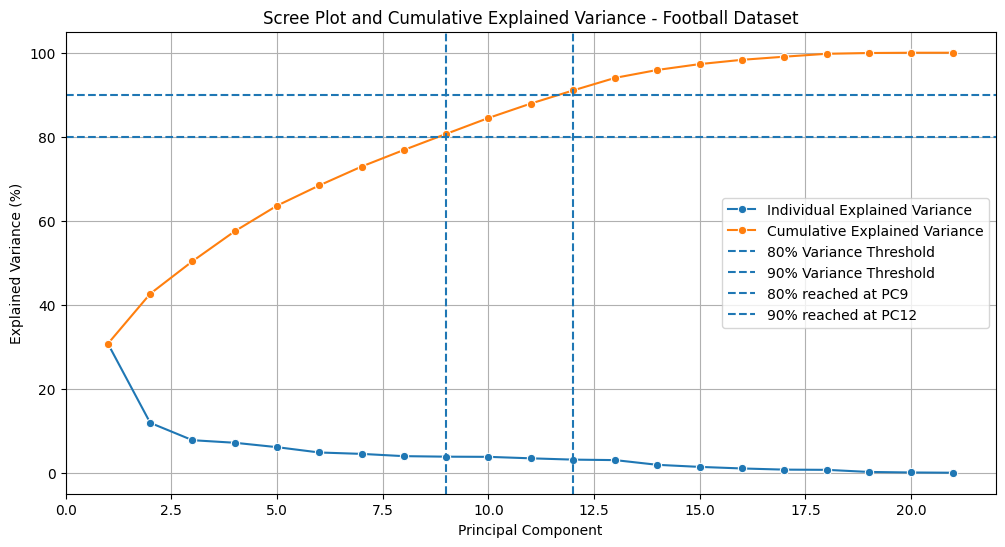

In [79]:
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=components,
    y=explained_variance_percent,
    marker="o",
    label="Individual Explained Variance"
)

sns.lineplot(
    x=components,
    y=cumulative_variance * 100,
    marker="o",
    label="Cumulative Explained Variance"
)

plt.axhline(
    y=80,
    linestyle="--",
    label="80% Variance Threshold"
)

plt.axhline(
    y=90,
    linestyle="--",
    label="90% Variance Threshold"
)

plt.axvline(
    x=pcs_80,
    linestyle="--",
    label=f"80% reached at PC{pcs_80}"
)

plt.axvline(
    x=pcs_90,
    linestyle="--",
    label=f"90% reached at PC{pcs_90}"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.title(
    "Scree Plot and Cumulative Explained Variance - Football Dataset"
)

plt.legend()
plt.grid(True)

plt.show()

In [80]:
pca_80 = PCA(n_components=pcs_80)

X_pca_80 = pca_80.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("Selected PCA components:", X_pca_80.shape[1])

Original features: 21
Selected PCA components: 9


In [81]:
pca_columns = [
    f"PC{i}"
    for i in range(1, pcs_80 + 1)
]

pca_df = pd.DataFrame(
    X_pca_80,
    columns=pca_columns
)

display(pca_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,6.776257,0.964842,2.087242,-1.357022,-1.960091,2.019589,2.372722,0.130974,0.978604
1,2.859669,1.687990,-1.744971,3.081570,1.216178,-0.635667,2.082965,0.041773,0.956661
2,6.046506,0.396209,0.687641,-1.548031,-0.418543,1.884183,-0.092543,0.440264,1.914607
3,1.615425,3.385081,1.335303,0.505797,1.513644,0.118398,0.121705,1.164404,0.424129
4,0.099353,3.122097,0.164511,2.019353,0.911523,1.351082,1.955002,0.328299,-0.176168


In [82]:
pca_analysis_df = pca_df.copy()

pca_analysis_df["Player_Future_Potential_Score"] = (
    df["Player_Future_Potential_Score"].values
)

pca_analysis_df["Player_Future_Potential_Rating"] = (
    df["Player_Future_Potential_Rating"].values
)

display(pca_analysis_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Player_Future_Potential_Score,Player_Future_Potential_Rating
0,6.776257,0.964842,2.087242,-1.357022,-1.960091,2.019589,2.372722,0.130974,0.978604,89,Outperforming
1,2.859669,1.687990,-1.744971,3.081570,1.216178,-0.635667,2.082965,0.041773,0.956661,61,Average
2,6.046506,0.396209,0.687641,-1.548031,-0.418543,1.884183,-0.092543,0.440264,1.914607,89,Outperforming
3,1.615425,3.385081,1.335303,0.505797,1.513644,0.118398,0.121705,1.164404,0.424129,38,Underperforming
4,0.099353,3.122097,0.164511,2.019353,0.911523,1.351082,1.955002,0.328299,-0.176168,33,Underperforming


In [83]:
loadings = pd.DataFrame(
    pca_80.components_.T,
    index=pca_features_final,
    columns=pca_columns
)

display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
height_in_cm,0.001844,0.046071,-0.214182,0.107701,0.424838,0.616017,0.250121,-0.348255,0.081709
international_caps,0.188978,-0.021927,0.104683,-0.004642,0.053873,-0.071799,-0.304755,-0.357690,-0.466599
market_value_in_eur,0.235992,0.102107,0.344269,-0.114691,0.374809,0.046807,-0.115527,0.229586,0.092503
highest_market_value_in_eur,0.332588,0.032985,0.271038,-0.073252,0.258430,0.007709,-0.097865,0.078655,0.058743
matches_played,0.349351,-0.134692,-0.180486,0.122867,-0.046255,-0.089051,-0.013415,-0.053031,0.010091
total_minutes,0.340661,-0.135400,-0.210518,0.164584,-0.000743,-0.087450,-0.015149,-0.018030,-0.005940
avg_minutes,0.098310,-0.119807,-0.239527,0.311331,0.166416,0.336484,0.115067,0.533939,-0.395072
total_goals,0.301235,-0.113450,0.061848,-0.175809,-0.177725,0.147740,0.066438,-0.255473,0.023978
avg_goals,0.159895,-0.074302,0.056325,-0.333169,-0.306016,0.387368,0.258903,-0.190330,0.119914
total_assists,0.327337,-0.119662,0.012448,-0.108018,-0.195648,-0.009255,0.019899,-0.044687,-0.057178


In [84]:
for pc in pca_columns:

    print("\n" + "=" * 60)
    print(f"Strongest Features for {pc}")
    print("=" * 60)

    strongest_features = (
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )

    print(strongest_features)


Strongest Features for PC1
matches_played                 0.349351
total_minutes                  0.340661
value_growth                   0.332986
highest_market_value_in_eur    0.332588
total_assists                  0.327337
Name: PC1, dtype: float64

Strongest Features for PC2
foreigners_number        0.520812
national_team_players    0.474677
foreigners_percentage    0.413677
squad_size               0.317551
stadium_seats            0.267774
Name: PC2, dtype: float64

Strongest Features for PC3
market_value_in_eur      0.344269
foreigners_percentage    0.338574
red_cards                0.299844
total_clubs              0.292268
foreigners_number        0.290954
Name: PC3, dtype: float64

Strongest Features for PC4
total_clubs      0.391511
average_age      0.357482
avg_goals        0.333169
avg_minutes      0.311331
stadium_seats    0.305782
Name: PC4, dtype: float64

Strongest Features for PC5
height_in_cm           0.424838
market_value_in_eur    0.374809
avg_assists           

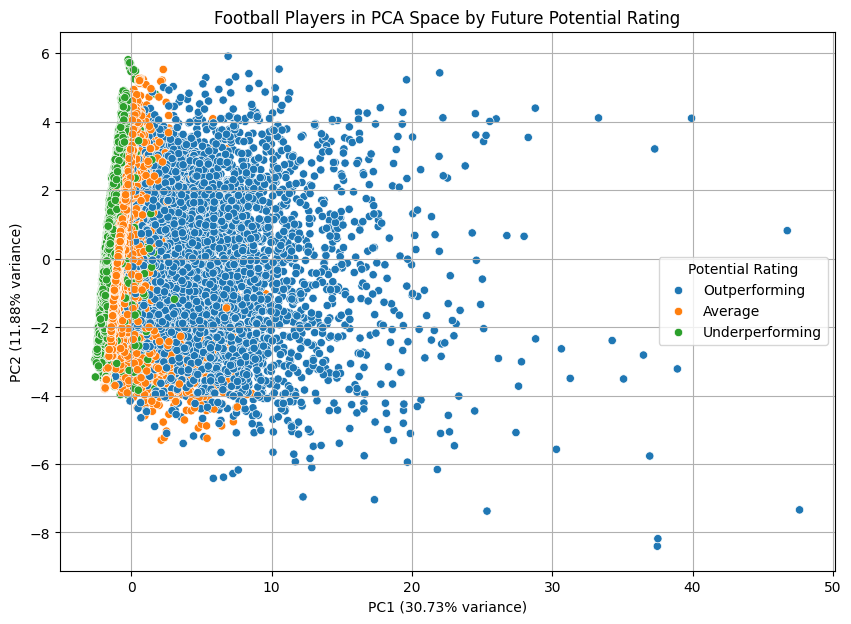

In [89]:
plot_df = pca_analysis_df[
    [
        "PC1",
        "PC2",
        "Player_Future_Potential_Rating"
    ]
].dropna()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Player_Future_Potential_Rating",
)

plt.xlabel(
    f"PC1 ({pca_80.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_80.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.title(
    "Football Players in PCA Space by Future Potential Rating"
)

plt.legend(title="Potential Rating")
plt.grid(True)

plt.show()

In [90]:
original_features = len(pca_features_final)
selected_features = pcs_80

reduction_percentage = (
    (original_features - selected_features)
    / original_features
) * 100

print(
    f"Dimensionality reduction: "
    f"{reduction_percentage:.2f}%"
)

Dimensionality reduction: 57.14%


In [97]:
# 1. Explained variance table
pca_summary.to_csv(
    "football_pca_explained_variance.csv",
    index=False
)

# 2. PCA-reduced dataset with target columns
pca_analysis_df.to_csv(
    "football_pca_dataset_80_percent.csv",
    index=False
)

# 3. Complete PCA loading matrix
loadings.to_csv(
    "football_pca_loadings.csv",
    index=True
)

print("=" * 60)
print("PCA OUTPUT FILES SAVED SUCCESSFULLY")
print("=" * 60)

print("1. football_pca_explained_variance.csv")
print("2. football_pca_dataset_80_percent.csv")
print("3. football_pca_loadings.csv")

PCA OUTPUT FILES SAVED SUCCESSFULLY
1. football_pca_explained_variance.csv
2. football_pca_dataset_80_percent.csv
3. football_pca_loadings.csv


In [98]:
selected_loadings = loadings[pca_columns].copy()
display(selected_loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
height_in_cm,0.001844,0.046071,-0.214182,0.107701,0.424838,0.616017,0.250121,-0.348255,0.081709
international_caps,0.188978,-0.021927,0.104683,-0.004642,0.053873,-0.071799,-0.304755,-0.357690,-0.466599
market_value_in_eur,0.235992,0.102107,0.344269,-0.114691,0.374809,0.046807,-0.115527,0.229586,0.092503
highest_market_value_in_eur,0.332588,0.032985,0.271038,-0.073252,0.258430,0.007709,-0.097865,0.078655,0.058743
matches_played,0.349351,-0.134692,-0.180486,0.122867,-0.046255,-0.089051,-0.013415,-0.053031,0.010091
total_minutes,0.340661,-0.135400,-0.210518,0.164584,-0.000743,-0.087450,-0.015149,-0.018030,-0.005940
avg_minutes,0.098310,-0.119807,-0.239527,0.311331,0.166416,0.336484,0.115067,0.533939,-0.395072
total_goals,0.301235,-0.113450,0.061848,-0.175809,-0.177725,0.147740,0.066438,-0.255473,0.023978
avg_goals,0.159895,-0.074302,0.056325,-0.333169,-0.306016,0.387368,0.258903,-0.190330,0.119914
total_assists,0.327337,-0.119662,0.012448,-0.108018,-0.195648,-0.009255,0.019899,-0.044687,-0.057178


In [99]:
for pc in pca_columns:

    print("\n" + "=" * 60)
    print(f"Strongest Features for {pc}")
    print("=" * 60)

    strongest_features = (
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )

    print(strongest_features)


Strongest Features for PC1
matches_played                 0.349351
total_minutes                  0.340661
value_growth                   0.332986
highest_market_value_in_eur    0.332588
total_assists                  0.327337
Name: PC1, dtype: float64

Strongest Features for PC2
foreigners_number        0.520812
national_team_players    0.474677
foreigners_percentage    0.413677
squad_size               0.317551
stadium_seats            0.267774
Name: PC2, dtype: float64

Strongest Features for PC3
market_value_in_eur      0.344269
foreigners_percentage    0.338574
red_cards                0.299844
total_clubs              0.292268
foreigners_number        0.290954
Name: PC3, dtype: float64

Strongest Features for PC4
total_clubs      0.391511
average_age      0.357482
avg_goals        0.333169
avg_minutes      0.311331
stadium_seats    0.305782
Name: PC4, dtype: float64

Strongest Features for PC5
height_in_cm           0.424838
market_value_in_eur    0.374809
avg_assists           

In [100]:
print("Target exclusion check:")
print()

for target in target_columns:

    if target in pca_features_final:
        print(f"ERROR: {target} is included in PCA.")
    else:
        print(f"OK: {target} is excluded from PCA.")

print("\nFinal PCA features:")
print(pca_features_final)

Target exclusion check:

OK: Player_Future_Potential_Score is excluded from PCA.
OK: Player_Future_Potential_Rating is excluded from PCA.

Final PCA features:
['height_in_cm', 'international_caps', 'market_value_in_eur', 'highest_market_value_in_eur', 'matches_played', 'total_minutes', 'avg_minutes', 'total_goals', 'avg_goals', 'total_assists', 'avg_assists', 'yellow_cards', 'red_cards', 'value_growth', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_seats', 'total_clubs']


In [102]:
original_features = len(pca_features_final)
selected_features = pcs_80

reduction_percentage = (
    (original_features - selected_features)
    / original_features
) * 100

print(
    f"Original features: {original_features}"
)

print(
    f"Selected PCA components: {selected_features}"
)

print(
    f"Dimensionality reduction: "
    f"{reduction_percentage:.2f}%"
)

Original features: 21
Selected PCA components: 9
Dimensionality reduction: 57.14%


In [103]:
# FINAL PCA SUMMARY

print("=" * 70)
print("FINAL PCA RESULTS - FOOTBALL PLAYER DATASET")
print("=" * 70)

print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

print(
    f"\nNumerical PCA features used: "
    f"{len(pca_features_final)}"
)

print(
    f"Selected PCA components: "
    f"{pcs_80}"
)

print(
    f"Variance retained: "
    f"{cumulative_variance[pcs_80 - 1] * 100:.2f}%"
)

print(
    f"\nComponents required for >=90% variance: "
    f"{pcs_90}"
)

print(
    f"Variance retained at >=90%: "
    f"{cumulative_variance[pcs_90 - 1] * 100:.2f}%"
)

print(
    f"\nDimensionality reduction: "
    f"{reduction_percentage:.2f}%"
)

print(
    f"\nPC1 explains: "
    f"{explained_variance_percent[0]:.2f}%"
)

print(
    f"PC2 explains: "
    f"{explained_variance_percent[1]:.2f}%"
)

print("\nPCA analysis completed successfully.")

FINAL PCA RESULTS - FOOTBALL PLAYER DATASET
Dataset rows: 50149
Dataset columns: 44

Numerical PCA features used: 21
Selected PCA components: 9
Variance retained: 80.67%

Components required for >=90% variance: 12
Variance retained at >=90%: 91.01%

Dimensionality reduction: 57.14%

PC1 explains: 30.73%
PC2 explains: 11.88%

PCA analysis completed successfully.
